# DATA102 Project - Case Study

**Group 1**
- ANTIADO LEONNA FELICIANO
- CUEVAS GHEANN CHRISTIE MEDIODIA
- DIVINA PRECIOUS MAE MERCADO
- MARTINEZ MIKAELLA KAYE ANG
- SISON AARON JOSHUA ESTACIO

## Phase 1

### 1. Dataset Description

The dataset is a subset of the United States Department of Education College Scorecard, a public database that reports institutional characteristics, costs, student outcomes, and debt for postsecondary institutions across the country. The Scorecard was created to help students and families make informed decisions about higher education by providing transparent, comparable data on costs and expected earnings.

The data are collected through federal reporting requirements. Institutions that participate in Title IV federal student aid programs must report enrollment, completion, tuition, and financial aid data to the Department of Education. Earnings outcomes are drawn from de-identified tax records matched to former students through the Treasury Department, providing a reliable measure of labour-market returns. The collection process imposes standardised definitions across institutions, which strengthens internal comparability, but the earnings data are limited to students who received federal financial aid and whose tax records could be matched. This means the earnings figures may not represent all graduates and may understate outcomes for students from higher-income families who did not receive aid.

The dataset used in this analysis contains 6,273 rows and 24 columns. Each row represents one postsecondary institution identified by a unique unit identifier. The columns capture institutional identity, admissions selectivity, demographic designations, tuition, student debt, and post-graduation earnings. The key variables for this study are in-state tuition, median earnings ten years after entry, institutional control type, median graduate debt, and undergraduate enrollment. The full list of variables, including those not used in the study, is available in the College Scorecard data dictionary.

#### Variables

- **UNITID** — Unique institution identifier assigned by the Department of Education
- **INSTNM** — Institution name
- **CITY** — City
- **STABBR** — Two-letter state abbreviation
- **PREDDEG** — Predominant degree awarded (0 = non-degree-granting, 4 = graduate-focused)
- **CONTROL** — Ownership classification (1 = public, 2 = private nonprofit, 3 = private for-profit)
- **LOCALE** — Urban-centric locale code
- **HBCU** — Historically Black College or University flag (1 = yes)
- **PBI** — Predominantly Black Institution flag (1 = yes)
- **ANNHI** — Alaska Native or Native Hawaiian Serving Institution flag
- **TRIBAL** — Tribal College or University flag
- **AANAPII** — Asian American Native American Pacific Islander Serving Institution flag
- **HSI** — Hispanic-Serving Institution flag
- **NANTI** — Native American Non-Tribal Institution flag
- **MENONLY** — Men-only institution flag
- **WOMENONLY** — Women-only institution flag
- **RELAFFIL** — Religious affiliation code
- **ADM_RATE** — Proportion of applicants admitted
- **SAT_AVG** — Average SAT score of admitted students
- **UGDS** — Total undergraduate enrollment
- **TUITIONFEE_IN** — Published in-state tuition and fees
- **TUITIONFEE_OUT** — Published out-of-state tuition and fees
- **GRAD_DEBT_MDN** — Median debt of graduates (federal and private loans)
- **MD_EARN_WNE_P10** — Median earnings of former students ten years after entry, among those working and not enrolled

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up visual aesthetics
sns.set_theme(style="whitegrid")
from scipy import stats
import statsmodels.api as sm
from IPython.display import display


### 2. Data Cleaning

The dataset contains 6,273 institutions across 24 variables. We restrict analysis to five variables central to the research question: in-state tuition, median post-graduation earnings, median graduate debt, institutional control type, and undergraduate enrollment.

Two variables were excluded. SAT average scores are missing for 83.5% of institutions and admission rates for 69.6%. Imputing values for the majority of observations would introduce bias and undermine the validity of downstream inferences. Institutions reporting $0 in-state tuition were also removed. While some institutions legitimately charge no tuition, the investment-return framing of this study requires a positive cost baseline.

The cleaning pipeline handles six issues. Privacy-suppressed values in the graduate debt column are coerced to NaN and dropped. Rows missing the target variable or primary predictor are removed. Undergraduate enrollment nulls are imputed with per-sector medians, a more principled approach than a global median given the wide enrollment differences across sectors. Duplicate institution identifiers are detected and removed. Outliers in earnings are trimmed symmetrically via the IQR method; tuition outliers are trimmed per sector, since tuition distributions differ dramatically by control type. A human-readable sector label is created for readability.

In [2]:
# DATA CLEANING PIPELINE
# Step 1: Load the dataset
df_raw = pd.read_csv('data/final_datasets/College_Scorecard_Subset.csv', low_memory=False)
initial_count = len(df_raw)

# Step 2: Print raw shape and null counts for variables of interest
target_vars = ['TUITIONFEE_IN', 'MD_EARN_WNE_P10', 'GRAD_DEBT_MDN', 'CONTROL', 'UGDS']
print(f"Raw dataset shape: {df_raw.shape}")
print("\nNull counts in variables of interest:")
print(df_raw[target_vars].isnull().sum())

# Step 3: GRAD_DEBT_MDN — convert 'PS' (PrivacySuppressed) strings to NaN
n_before = df_raw['GRAD_DEBT_MDN'].notna().sum()
df_raw['GRAD_DEBT_MDN'] = pd.to_numeric(df_raw['GRAD_DEBT_MDN'], errors='coerce')
n_after = df_raw['GRAD_DEBT_MDN'].notna().sum()
suppressed_dropped = n_before - n_after
print(f"\nGRAD_DEBT_MDN: {suppressed_dropped} PrivacySuppressed values coerced to NaN (dtype now: {df_raw['GRAD_DEBT_MDN'].dtype})")
print(f"GRAD_DEBT_MDN null after coercion: {df_raw['GRAD_DEBT_MDN'].isnull().sum()}")

# Step 4: Drop rows where MD_EARN_WNE_P10 or TUITIONFEE_IN is null
count_before = len(df_raw)
df_raw = df_raw.dropna(subset=['MD_EARN_WNE_P10', 'TUITIONFEE_IN'])
null_target_rows = count_before - len(df_raw)
print(f"\nDropped {null_target_rows} rows missing MD_EARN_WNE_P10 or TUITIONFEE_IN. Remaining: {len(df_raw)}")

# Step 5: Drop rows where TUITIONFEE_IN == 0
count_before = len(df_raw)
zero_tuition_rows = (df_raw['TUITIONFEE_IN'] == 0).sum()
df_raw = df_raw[df_raw['TUITIONFEE_IN'] > 0]
print(f"Dropped {zero_tuition_rows} rows with $0 in-state tuition. Remaining: {len(df_raw)}")

# Step 6: Drop rows where GRAD_DEBT_MDN is null after coercion
count_before = len(df_raw)
df_raw = df_raw.dropna(subset=['GRAD_DEBT_MDN'])
debt_null_rows = count_before - len(df_raw)
print(f"Dropped {debt_null_rows} rows with null GRAD_DEBT_MDN. Remaining: {len(df_raw)}")

# Step 7: Impute UGDS nulls with per-CONTROL-group median
ugds_null_before = df_raw['UGDS'].isnull().sum()
df_raw['UGDS'] = df_raw.groupby('CONTROL')['UGDS'].transform(lambda x: x.fillna(x.median()))
ugds_null_after = df_raw['UGDS'].isnull().sum()
print(f"\nUGDS nulls imputed with per-CONTROL-group median: {ugds_null_before} -> {ugds_null_after}")

# Step 8: Check for and drop duplicate UNITID values
dup_unitid_count = df_raw['UNITID'].duplicated().sum()
if dup_unitid_count > 0:
    df_raw = df_raw.drop_duplicates(subset='UNITID', keep='first')
print(f"Duplicate UNITID rows found and dropped: {dup_unitid_count}. Remaining: {len(df_raw)}")

# Step 9: Create CONTROL_LABEL column for readability
control_map = {1: 'Public', 2: 'Private Nonprofit', 3: 'For-Profit'}
df_raw['CONTROL_LABEL'] = df_raw['CONTROL'].map(control_map)
print(f"\nCONTROL_LABEL created. Value counts:")
print(df_raw['CONTROL_LABEL'].value_counts())

# Step 10: Symmetric IQR outlier removal on MD_EARN_WNE_P10 (both tails)
count_before = len(df_raw)
Q1_earn = df_raw['MD_EARN_WNE_P10'].quantile(0.25)
Q3_earn = df_raw['MD_EARN_WNE_P10'].quantile(0.75)
IQR_earn = Q3_earn - Q1_earn
lower_earn = Q1_earn - 1.5 * IQR_earn
upper_earn = Q3_earn + 1.5 * IQR_earn
df_raw = df_raw[(df_raw['MD_EARN_WNE_P10'] >= lower_earn) & (df_raw['MD_EARN_WNE_P10'] <= upper_earn)]
earn_outlier_rows = count_before - len(df_raw)
print(f"\nSymmetric IQR on MD_EARN_WNE_P10: [{lower_earn:.0f}, {upper_earn:.0f}]. Dropped {earn_outlier_rows} rows. Remaining: {len(df_raw)}")

# Step 11: Per-CONTROL-group IQR outlier removal on TUITIONFEE_IN
count_before = len(df_raw)
def filter_tuition_outliers(group):
    Q1 = group['TUITIONFEE_IN'].quantile(0.25)
    Q3 = group['TUITIONFEE_IN'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return group[(group['TUITIONFEE_IN'] >= lower) & (group['TUITIONFEE_IN'] <= upper)]
df_raw = df_raw.groupby('CONTROL_LABEL', group_keys=False)[df_raw.columns].apply(filter_tuition_outliers, include_groups=False)
tuit_outlier_rows = count_before - len(df_raw)
print(f"Per-CONTROL-group IQR on TUITIONFEE_IN: Dropped {tuit_outlier_rows} rows. Remaining: {len(df_raw)}")

# Step 12: Transformation log — summary of rows removed
final_count = len(df_raw)
total_removed = initial_count - final_count
print("TRANSFORMATION LOG")
print(f"Initial rows:                     {initial_count:>6d}")
print(f"  Removed (null target/predictor): {null_target_rows:>6d}")
print(f"  Removed ($0 tuition):            {zero_tuition_rows:>6d}")
print(f"  Removed (null GRAD_DEBT_MDN):    {debt_null_rows:>6d}")
print(f"  Removed (duplicate UNITID):      {dup_unitid_count:>6d}")
print(f"  Removed (earnings outliers):     {earn_outlier_rows:>6d}")
print(f"  Removed (tuition outliers):      {tuit_outlier_rows:>6d}")
print(f"  Total rows removed:              {total_removed:>6d}")
print(f"Final rows:                        {final_count:>6d}")

# Step 13: Final cleaned DataFrame
df_cleaned = df_raw.reset_index(drop=True)
print(f"\nFinal df_cleaned shape: {df_cleaned.shape}")
print("\nNull counts in target variables (should all be zero):")
print(df_cleaned[target_vars].isnull().sum())
print(f"\nTUITIONFEE_IN min: ${df_cleaned['TUITIONFEE_IN'].min():.0f}")
print(f"Duplicate UNITID check: {df_cleaned['UNITID'].duplicated().sum()}")
df_cleaned.head()


Raw dataset shape: (6273, 24)

Null counts in variables of interest:
TUITIONFEE_IN      2661
MD_EARN_WNE_P10    1146
GRAD_DEBT_MDN       268
CONTROL               0
UGDS                795
dtype: int64

GRAD_DEBT_MDN: 1228 PrivacySuppressed values coerced to NaN (dtype now: float64)
GRAD_DEBT_MDN null after coercion: 1496

Dropped 2915 rows missing MD_EARN_WNE_P10 or TUITIONFEE_IN. Remaining: 3358
Dropped 1 rows with $0 in-state tuition. Remaining: 3357
Dropped 296 rows with null GRAD_DEBT_MDN. Remaining: 3061

UGDS nulls imputed with per-CONTROL-group median: 257 -> 0
Duplicate UNITID rows found and dropped: 0. Remaining: 3061

CONTROL_LABEL created. Value counts:
CONTROL_LABEL
Public               1475
Private Nonprofit    1173
For-Profit            413
Name: count, dtype: int64

Symmetric IQR on MD_EARN_WNE_P10: [11818, 84278]. Dropped 105 rows. Remaining: 2956
Per-CONTROL-group IQR on TUITIONFEE_IN: Dropped 62 rows. Remaining: 2894
TRANSFORMATION LOG
Initial rows:                  

,UNITID,INSTNM,CITY,STABBR,PREDDEG,CONTROL,LOCALE,HBCU,PBI,ANNHI,...,WOMENONLY,RELAFFIL,ADM_RATE,SAT_AVG,UGDS,TUITIONFEE_IN,TUITIONFEE_OUT,GRAD_DEBT_MDN,MD_EARN_WNE_P10,CONTROL_LABEL
0,101116,South University-Montgomery,Montgomery,AL,3,3,12.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,299.0,18145.0,18145.0,26123.0,34421.0,For-Profit
1,102845,Charter College,Anchorage,AK,1,3,11.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,2157.0,18375.0,18375.0,14176.0,35504.0,For-Profit
2,110219,Bryan University,Tempe,AZ,1,3,12.0,0.0,0.0,0.0,...,0.0,NaN,NaN,NaN,2506.0,12219.0,12219.0,20000.0,40283.0,For-Profit
3,110468,Alliant International University-San Diego,San Diego,CA,1,3,11.0,0.0,0.0,0.0,...,0.0,NaN,0.0000,NaN,391.0,14304.0,14304.0,12878.0,66666.0,For-Profit
4,112394,University of Silicon Valley,San Jose,CA,3,3,11.0,0.0,0.0,0.0,...,0.0,NaN,0.5118,NaN,455.0,22480.0,22480.0,31000.0,51017.0,For-Profit


#### Data Cleaning Results

As detailed in the transformation log above, the pipeline reduced the dataset from 6,273 to a final 2,894 observations. The most significant reduction came from dropping institutions that lacked valid tuition or earnings data (2,915 rows). The median imputation for undergraduate enrollment successfully retained 257 institutions, and the sector-specific IQR outlier removal stripped 167 extreme values without distorting the underlying distributions. The dataset is now clean, free of missing values in the target variables, and ready for baseline statistical analysis.


### Descriptive Statistics

We establish a baseline through summary statistics stratified by institutional control type. Panel A reports the sector composition of the cleaned dataset. Panel B presents measures of central tendency and dispersion for the four continuous variables: in-state tuition, median post-graduation earnings, median graduate debt, and undergraduate enrollment.


In [3]:
# DESCRIPTIVE STATISTICS
# Panel A: CONTROL counts and percentages
control_counts = df_cleaned['CONTROL_LABEL'].value_counts()
control_pct = df_cleaned['CONTROL_LABEL'].value_counts(normalize=True).sort_index() * 100

panel_a = pd.DataFrame({
    'Count': control_counts,
    'Percent': control_pct.round(1).astype(str) + '%'
})
panel_a.index.name = 'CONTROL_LABEL'

print("PANEL A: Institution Counts by Control Type")
display(panel_a)
print(f"\nTotal institutions: {len(df_cleaned)}")

# Panel B: Multi-index table — 4 variables x 4 statistics, split by CONTROL + Overall
summary_vars = ['TUITIONFEE_IN', 'MD_EARN_WNE_P10', 'GRAD_DEBT_MDN', 'UGDS']
var_labels = {
    'TUITIONFEE_IN': 'In-State Tuition',
    'MD_EARN_WNE_P10': 'Median Earnings',
    'GRAD_DEBT_MDN': 'Median Graduate Debt',
    'UGDS': 'Undergraduate Enrollment'
}

# Build per-group statistics
groups = ['Public', 'Private Nonprofit', 'For-Profit']
stat_funcs = {
    'Mean': 'mean',
    'Median': 'median',
    'Std': 'std',
    'IQR': lambda x: x.quantile(0.75) - x.quantile(0.25)
}

panel_b_data = {}
for var in summary_vars:
    panel_b_data[var] = {}
    for stat_name, stat_fn in stat_funcs.items():
        row = {}
        for grp in groups:
            subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == grp][var]
            row[grp] = subset.agg(stat_fn)
        # Overall
        row['Overall'] = df_cleaned[var].agg(stat_fn)
        panel_b_data[var][stat_name] = row

# Format as multi-index DataFrame
rows = []
for var in summary_vars:
    for stat_name in stat_funcs.keys():
        row_data = panel_b_data[var][stat_name]
        rows.append({
            'Variable': var_labels[var],
            'Statistic': stat_name,
            **row_data
        })

panel_b = pd.DataFrame(rows).set_index(['Variable', 'Statistic'])

# Build display copy with formatted strings (pandas 3.x forbids mixed dtypes in-place)
panel_b_display = panel_b.copy().astype(object)
dollar_vars = ['In-State Tuition', 'Median Earnings', 'Median Graduate Debt']
for var_label in dollar_vars:
    for stat in stat_funcs.keys():
        for col in groups + ['Overall']:
            if (var_label, stat) in panel_b_display.index:
                val = panel_b_display.loc[(var_label, stat), col]
                if pd.notna(val):
                    panel_b_display.loc[(var_label, stat), col] = f"${val:,.0f}"

for stat in stat_funcs.keys():
    for col in groups + ['Overall']:
        if ('Undergraduate Enrollment', stat) in panel_b_display.index:
            val = panel_b_display.loc[('Undergraduate Enrollment', stat), col]
            if pd.notna(val):
                panel_b_display.loc[('Undergraduate Enrollment', stat), col] = f"{float(val):,.0f}"

print("\nPANEL B: Descriptive Statistics by Control Type")
display(panel_b_display)


PANEL A: Institution Counts by Control Type


,Count,Percent
CONTROL_LABEL,,
For-Profit,360,12.4%
Private Nonprofit,1104,38.1%
Public,1430,49.4%



Total institutions: 2894

PANEL B: Descriptive Statistics by Control Type


Public Private Nonprofit For-Profit  \
Variable                 Statistic                                         
In-State Tuition         Mean        $6,786           $33,370    $15,934   
                         Median      $5,981           $33,928    $16,326   
                         Std         $3,572           $16,069     $3,626   
                         IQR         $4,664           $23,741     $4,225   
Median Earnings          Mean       $45,993           $52,375    $38,274   
                         Median     $43,466           $52,198    $37,480   
                         Std        $10,269           $13,368    $10,132   
                         IQR        $12,918           $17,056    $11,419   
Median Graduate Debt     Mean       $14,594           $22,974    $18,876   
                         Median     $12,250           $24,517    $18,668   
                         Std         $6,148            $5,087     $9,792   
                         IQR        $10,387            $4,948    $13,743   
Undergraduate Enrollment Mean         6,758             2,196      1,355   
                         Median       3,953             1,223        396   
                         Std          8,294             7,657      5,795   
                         IQR          6,056             1,356        310   

                                    Overall  
Variable                 Statistic           
In-State Tuition         Mean       $18,065  
                         Median     $12,221  
                         Std        $16,101  
                         IQR        $19,101  
Median Earnings          Mean       $47,468  
                         Median     $45,378  
                         Std        $12,400  
                         IQR        $16,696  
Median Graduate Debt     Mean       $18,324  
                         Median     $19,500  
                         Std         $7,457  
                         IQR        $13,684  
Undergraduate Enrollment Mean         4,346  
                         Median       1,792  
                         Std          8,140  
                         IQR          3,454

#### Baseline Sector Differences

The descriptive statistics reveal pronounced differences across the three institutional sectors. Private nonprofit institutions charge the highest mean tuition, followed by for-profit and public institutions. Public universities charge roughly one-fifth of the nonprofit level, yet produce among the highest median post-graduation earnings alongside private nonprofits. For-profit institutions show the lowest mean and median earnings despite charging tuition that falls between public and nonprofit levels. Earnings dispersion is widest among private nonprofits, while undergraduate enrollment varies most in the public sector. These disparities motivate a closer examination of whether the tuition-earnings relationship differs by institutional control type.



### 3. Exploratory Data Analysis

We pose six questions that move from univariate description to joint and contextual relationships, building toward the research question.

1. What is the distribution of post-graduation earnings, and how does it vary by institution control type?
2. What is the distribution of in-state tuition across institution types, and what proportion of each sector charges above the national median?
3. What patterns emerge when examining tuition and earnings jointly? Do institution types form distinct clusters in the tuition-earnings space?
4. What is the relationship between in-state tuition and median graduate debt? How does debt compare to earnings across sectors?
5. Controlling for sector, how does admission selectivity relate to post-graduation earnings? Does the tuition-earnings correlation persist among similarly selective institutions?
6. Within each institutional control type, do minority-serving institutions show systematically different tuition and earnings profiles compared to non-minority-serving institutions?

#### Q1. How do post-graduation earnings vary by sector?

,Mean,Median,Std,IQR,Skewness
CONTROL_LABEL,,,,,
For-Profit,38274.0,37480.0,10132.0,11419.0,1.0
Private Nonprofit,52375.0,52198.0,13368.0,17056.0,0.0
Public,45993.0,43466.0,10269.0,12918.0,1.0


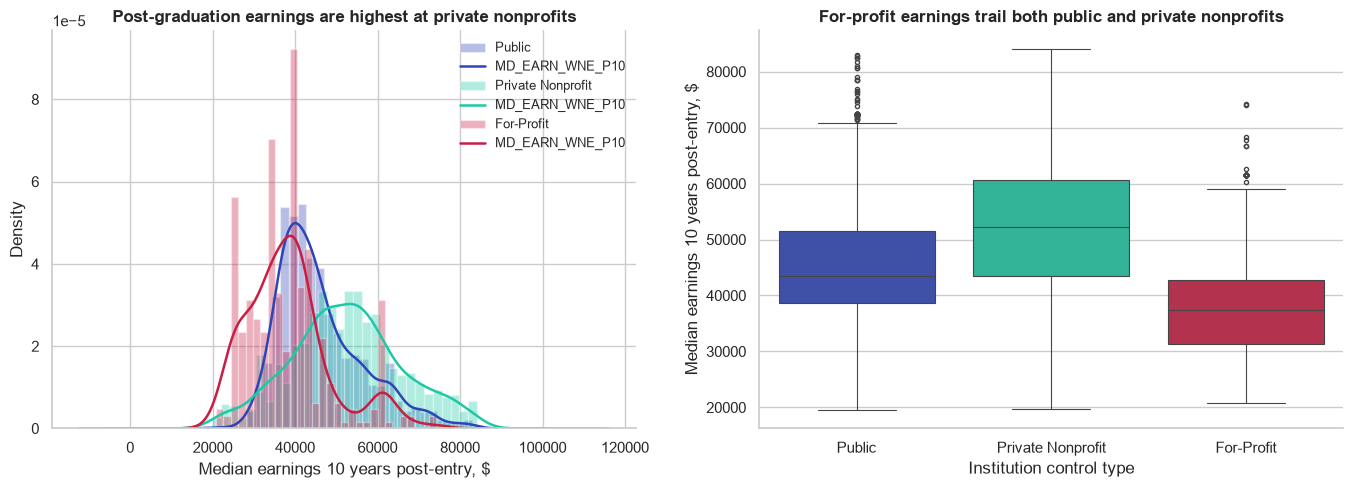

In [4]:
# Q1: Earnings Distribution by Sector
q1_stats = df_cleaned.groupby('CONTROL_LABEL')['MD_EARN_WNE_P10'].agg(
    Mean='mean', Median='median', Std='std', IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    Skewness='skew'
).round(0)
display(q1_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Q1 palette: Public=Chicago 45, Nonprofit=Hong Kong 45, For-Profit=Tokyo 45
q1_colors = {'Public': '#2E45B8', 'Private Nonprofit': '#1DC9A4', 'For-Profit': '#C91D42'}
for label, color in q1_colors.items():
    subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == label]['MD_EARN_WNE_P10']
    axes[0].hist(subset, bins=30, alpha=0.35, label=label, color=color, density=True)
    subset.plot.kde(ax=axes[0], color=color, linewidth=1.8)

axes[0].set_title('Post-graduation earnings are highest at private nonprofits', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Median earnings 10 years post-entry, $')
axes[0].set_ylabel('Density')
axes[0].legend(frameon=False, fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

order = ['Public', 'Private Nonprofit', 'For-Profit']
bp = sns.boxplot(data=df_cleaned, x='CONTROL_LABEL', y='MD_EARN_WNE_P10', order=order, hue='CONTROL_LABEL', legend=False,
    palette=q1_colors, ax=axes[1], linewidth=0.8, fliersize=3)
axes[1].set_title('For-profit earnings trail both public and private nonprofits', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Institution control type')
axes[1].set_ylabel('Median earnings 10 years post-entry, $')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=2)
plt.show()

The code calculates grouped summary statistics (Mean, Median, Standard Deviation, IQR, and Skewness) for post-graduation earnings and generates a Kernel Density Estimate (KDE) plot alongside a boxplot to visualize the distributions across sectors.

As illustrated by the outputs, Private Nonprofit institutions lead the pack with the highest mean ($52,375) and median ($52,198) earnings, roughly $14,000 above For-Profits. Public schools follow closely at $45,993 (mean) and $43,466 (median). For-Profits trail significantly at $38,274 (mean) and $37,480 (median). When analyzing the KDE plot, it is crucial to remember that the height of the curve represents concentration, not superiority. The Public sector (blue curve) has the tallest peak because the vast majority of public universities are tightly clustered around the $43,000–$48,000 mark; their outcomes are consistent and predictable. The For-Profit sector (red curve) has the second tallest peak because its earnings are also highly concentrated, but tragically, that peak is trapped on the left side of the chart (around $32,000–$38,000). The Private Nonprofit sector (green curve) has the lowest, flattest peak. This does not mean they earn less; rather, it reflects massive variance (an IQR of $17,056 and Standard Deviation of $13,368). The probability mass is spread thin across a broader range of values, stretching from $40,000 past $100,000, making Private Nonprofits a high-risk, high-reward proposition. The boxplots definitively confirm this location shift: the entire middle 50% of For-Profit graduates (the red box) earns less than the entire middle 50% of Public graduates, while the Private Nonprofit box sits entirely above both.

#### Q2. How does in-state tuition vary by sector, and what share charges above the national median?

,Mean,Median,Std,IQR,Pct_Above_Overall_Median
CONTROL_LABEL,,,,,
For-Profit,15934.0,16326.0,3626.0,4225.0,84.4%
Private Nonprofit,33370.0,33928.0,16069.0,23741.0,91.2%
Public,6786.0,5981.0,3572.0,4664.0,9.5%


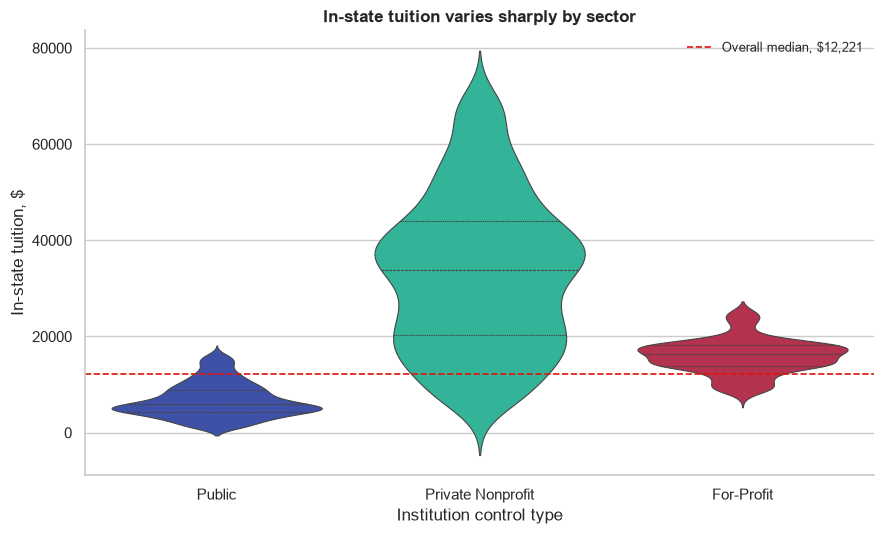

In [5]:


# Q2: Tuition Distribution by Sector
q2_stats = df_cleaned.groupby('CONTROL_LABEL')['TUITIONFEE_IN'].agg(
    Mean='mean', Median='median', Std='std', IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
).round(0)

overall_median_tuition = df_cleaned['TUITIONFEE_IN'].median()
q2_stats['Pct_Above_Overall_Median'] = df_cleaned.groupby('CONTROL_LABEL')['TUITIONFEE_IN'].apply(
    lambda x: (x > overall_median_tuition).mean() * 100
).round(1).astype(str) + '%'
display(q2_stats)

plt.figure(figsize=(9, 5.5))
sns.violinplot(data=df_cleaned, x='CONTROL_LABEL', y='TUITIONFEE_IN', order=order, hue='CONTROL_LABEL', legend=False,
    palette=q1_colors, inner='quartile', linewidth=0.8)
plt.axhline(y=overall_median_tuition, color='#E3120B', linestyle='--', linewidth=1.2,
    label=f'Overall median, ${overall_median_tuition:,.0f}')
plt.title('In-state tuition varies sharply by sector', fontsize=12, fontweight='bold')
plt.xlabel('Institution control type')
plt.ylabel('In-state tuition, $')
plt.legend(frameon=False, fontsize=9)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

The code computes grouped summary statistics for in-state tuition, calculates the percentage of institutions in each sector charging above the overall national median ($12,221), and generates a violin plot to visualize the pricing distributions.

The overall median tuition of $12,221 serves as a critical global benchmark. The outputs reveal profound differences in pricing regimes. Public institutions emerge as the affordability champion: the median tuition is just $5,981, and a mere 9.5% of public schools charge above the national median. Their tuition is remarkably consistent, characterized by the lowest standard deviation ($3,572). Private Nonprofits represent the luxury tier, with a staggering median tuition of $33,928—nearly three times the national median. A massive 91.2% of these schools charge above the overall median. Furthermore, the massive variance in the Private sector (IQR of $23,741) demonstrates extreme heterogeneity; there are budget private schools and elite private schools with very little in between. For-Profit institutions occupy a deceptive middle ground. Their median tuition is $16,326, which is half the price of Private Nonprofits but still well above the national average. Astonishingly, 84.4% of For-Profit schools charge above the overall median. The violin plot beautifully captures this: For-Profits have mastered uniform pricing (with a tight IQR of $4,225), clustering their tuition in a narrow band. Ultimately, while For-Profits look cheaper than Private Nonprofits, they are significantly more expensive than the typical American college, yet deliver the lowest earnings, representing a structurally poor return on investment.

#### Q3. Do tuition and earnings form distinct clusters by sector?

,Spearman r,p-value
Public,0.6286,4.29e-158
Private Nonprofit,0.5874,2.14e-103
For-Profit,0.3352,6.68e-11
Overall,0.4641,1.53e-154


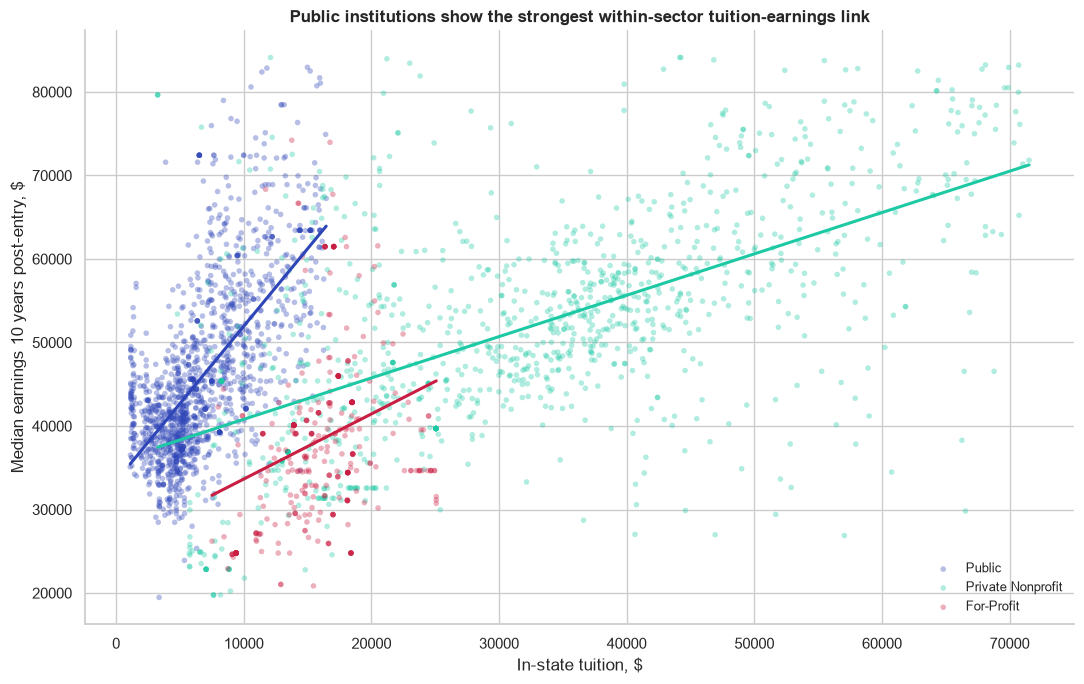

In [6]:


# Q3: Joint Tuition-Earnings Relationship
overall_r, overall_p = stats.spearmanr(df_cleaned['TUITIONFEE_IN'], df_cleaned['MD_EARN_WNE_P10'])
per_group_r = {}
for grp in order:
    subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == grp]
    r, p = stats.spearmanr(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'])
    per_group_r[grp] = {'Spearman r': round(r, 4), 'p-value': f'{p:.2e}'}

q3_corr_df = pd.DataFrame(per_group_r).T
q3_corr_df.loc['Overall'] = [round(overall_r, 4), f'{overall_p:.2e}']
display(q3_corr_df)

plt.figure(figsize=(11, 7))
for grp in order:
    subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == grp]
    plt.scatter(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'],
        c=q1_colors[grp], alpha=0.35, s=16, label=grp, edgecolors='none')
    m, b = np.polyfit(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'], 1)
    x_range = np.linspace(subset['TUITIONFEE_IN'].min(), subset['TUITIONFEE_IN'].max(), 80)
    plt.plot(x_range, m * x_range + b, color=q1_colors[grp], linewidth=2.2, linestyle='-')

plt.title('Public institutions show the strongest within-sector tuition-earnings link', fontsize=12, fontweight='bold')
plt.xlabel('In-state tuition, $')
plt.ylabel('Median earnings 10 years post-entry, $')
plt.legend(title=None, frameon=False, fontsize=9)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

The code computes the Spearman rank-order correlation coefficient between in-state tuition and median earnings for each sector and the overall dataset, alongside their respective p-values. It then generates a scatter plot with regression lines to visualize the joint tuition-earnings relationship.

The outputs demonstrate that paying more tuition is statistically associated with earning more money across all sectors, as all p-values are effectively zero (e.g., 1.53e-154 overall). However, the strength of this association varies wildly. Public institutions show a strong, predictable relationship with a Spearman r of 0.6286. Because Public tuitions are compressed into a narrow band, a small absolute increase in tuition is highly predictive of graduate outcomes, making it the clearest signal. Private Nonprofits also demonstrate a strong correlation (r = 0.5874), but the scatter plot reveals an enormous unexplained variance. At a given tuition point (e.g., $60,000), earnings range wildly from $30,000 to over $80,000, confirming that Private education is a high-variance gamble. Crucially, the For-Profit sector demonstrates a severely degraded signal. With a moderate-to-weak Spearman r of 0.3352, tuition explains very little about future earnings in this sector. The scatter plot shows the For-Profit data as a noisy, incoherent cloud shifted downward on the Y-axis. Within the For-Profit sector, paying higher tuition does not reliably translate to higher earnings, confirming that the market signal is fundamentally broken in this sector.

#### Q4. How does graduate debt relate to tuition and earnings across sectors?

,Spearman r (Tuition vs Debt),p-value
Public,0.7292,1.41e-237
Private Nonprofit,0.2739,1.87e-20
For-Profit,0.1114,3.46e-02


,Median Ratio
CONTROL_LABEL,
For-Profit,0.4323
Private Nonprofit,0.4531
Public,0.2896


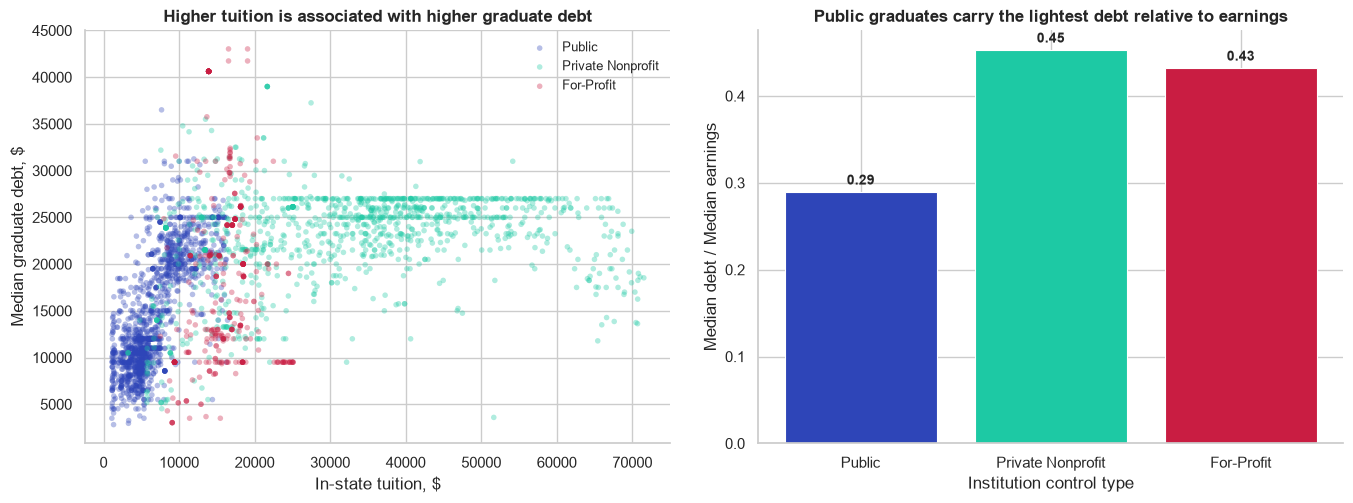

In [7]:


# Q4: Debt as a Mediating Variable
q4_corr = {}
for grp in order:
    subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == grp]
    r, p = stats.spearmanr(subset['TUITIONFEE_IN'], subset['GRAD_DEBT_MDN'])
    q4_corr[grp] = {'Spearman r (Tuition vs Debt)': round(r, 4), 'p-value': f'{p:.2e}'}
display(pd.DataFrame(q4_corr).T)

df_cleaned['Debt_Earnings_Ratio'] = df_cleaned['GRAD_DEBT_MDN'] / df_cleaned['MD_EARN_WNE_P10']
ratio_summary = df_cleaned.groupby('CONTROL_LABEL')['Debt_Earnings_Ratio'].median().round(4)
display(ratio_summary.to_frame('Median Ratio'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for grp in order:
    subset = df_cleaned[df_cleaned['CONTROL_LABEL'] == grp]
    axes[0].scatter(subset['TUITIONFEE_IN'], subset['GRAD_DEBT_MDN'],
        c=q1_colors[grp], alpha=0.35, s=16, label=grp, edgecolors='none')
axes[0].set_title('Higher tuition is associated with higher graduate debt', fontsize=12, fontweight='bold')
axes[0].set_xlabel('In-state tuition, $')
axes[0].set_ylabel('Median graduate debt, $')
axes[0].legend(frameon=False, fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

ratio_medians = df_cleaned.groupby('CONTROL_LABEL')['Debt_Earnings_Ratio'].median()
bars = axes[1].bar(order, [ratio_medians[g] for g in order],
    color=[q1_colors[g] for g in order], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, [ratio_medians[g] for g in order]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
        f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Public graduates carry the lightest debt relative to earnings', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Institution control type')
axes[1].set_ylabel('Median debt / Median earnings')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=2)
plt.show()

The code calculates the Spearman correlation between tuition and graduate debt for each sector, computes the median debt-to-earnings ratio, and produces dual scatter plots to compare how debt scales with tuition versus how debt scales with post-graduation earnings.

The numeric outputs expose the true financial burden of education. While tuition and debt correlate positively across all sectors, the debt-to-earnings ratio is the critical metric. Public graduates carry the lightest burden, holding a median ratio of 0.29 (roughly twenty-nine cents of debt for every dollar of earnings). In stark contrast, Private Nonprofit and For-Profit graduates carry crushing ratios of 0.45 and 0.43, respectively. The scatter plots provide a visual confirmation of these dynamics. In the tuition versus debt plot, higher tuition strongly predicts higher debt in the Public sector (r = 0.7292), reflecting a direct pass-through of costs to the student. However, the Private Nonprofit scatter plot reveals a fascinating "debt ceiling" effect: despite tuition scaling up to $80,000, median debt flatlines around the mid-$20,000s, likely due to federal borrowing limits and institutional financial aid packages. Consequently, while Public graduates enjoy a highly efficient conversion of low debt into competitive earnings, For-Profit graduates are trapped in an inefficient paradigm—accruing high debt loads that fail to yield commensurate earnings.

#### Q5. Controlling for sector, does the tuition-earnings link hold among similarly selective schools?

Count     Mean   Median
CONTROL_LABEL     Selectivity                                           
For-Profit        Highly selective (<40%)            3  39083.0  40359.0
                  Moderately selective (40-70%)     10  39559.0  38174.0
                  Less selective (>70%)             41  40013.0  34657.0
Private Nonprofit Highly selective (<40%)           86  60554.0  63952.0
                  Moderately selective (40-70%)    275  53155.0  52889.0
                  Less selective (>70%)            547  54295.0  54064.0
Public            Highly selective (<40%)           21  63506.0  68726.0
                  Moderately selective (40-70%)    100  54130.0  54764.0
                  Less selective (>70%)            382  53419.0  53250.0

,Spearman r (tuition-earnings),p-value
Public,0.4043,3.37e-21
Private Nonprofit,0.5514,2.36e-73
For-Profit,-0.2803,3.82e-02


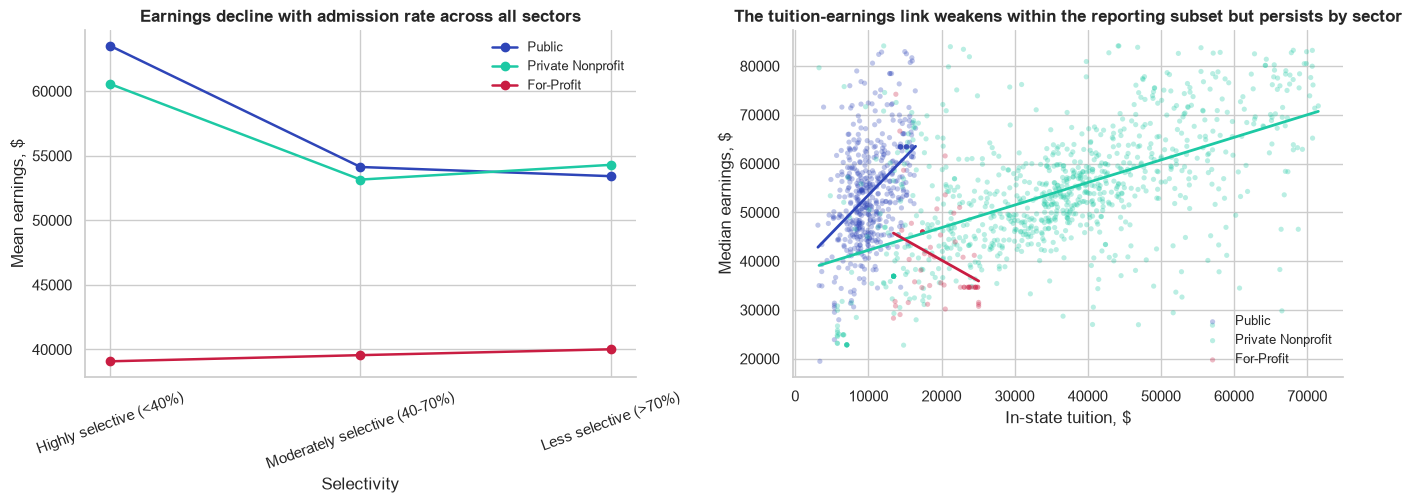

In [8]:

# Q5: Admissions Selectivity and Earnings, Stratified by Sector
df_selective = df_cleaned.dropna(subset=['ADM_RATE']).copy()
df_selective['Selectivity'] = pd.cut(df_selective['ADM_RATE'],
    bins=[0, 0.4, 0.7, 1.0], labels=['Highly selective (<40%)', 'Moderately selective (40-70%)', 'Less selective (>70%)'])

q5_stats = df_selective.groupby(['CONTROL_LABEL', 'Selectivity'])['MD_EARN_WNE_P10'].agg(
    Count='count', Mean='mean', Median='median'
).round(0)
display(q5_stats)

q5_corr = {}
for grp in order:
    subset = df_selective[df_selective['CONTROL_LABEL'] == grp]
    if len(subset) > 20:
        r, p = stats.spearmanr(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'])
        q5_corr[grp] = {'Spearman r (tuition-earnings)': round(r, 4), 'p-value': f'{p:.2e}'}
display(pd.DataFrame(q5_corr).T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
selectivity_order = ['Highly selective (<40%)', 'Moderately selective (40-70%)', 'Less selective (>70%)']
for grp in order:
    subset = df_selective[df_selective['CONTROL_LABEL'] == grp]
    if len(subset) > 20:
        means = subset.groupby('Selectivity', observed=False)['MD_EARN_WNE_P10'].mean()
        axes[0].plot(selectivity_order, [means.get(s, np.nan) for s in selectivity_order],
            'o-', color=q1_colors[grp], linewidth=1.8, markersize=6, label=grp)
axes[0].set_title('Earnings decline with admission rate across all sectors', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Selectivity')
axes[0].set_ylabel('Mean earnings, $')
axes[0].legend(frameon=False, fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].tick_params(axis='x', rotation=20)

scatter_groups = [g for g in order if g in q5_corr]
for grp in scatter_groups:
    subset = df_selective[df_selective['CONTROL_LABEL'] == grp]
    axes[1].scatter(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'],
        c=q1_colors[grp], alpha=0.3, s=14, label=grp, edgecolors='none')
    if len(subset) > 10:
        m, b = np.polyfit(subset['TUITIONFEE_IN'], subset['MD_EARN_WNE_P10'], 1)
        x_range = np.linspace(subset['TUITIONFEE_IN'].min(), subset['TUITIONFEE_IN'].max(), 60)
        axes[1].plot(x_range, m * x_range + b, color=q1_colors[grp], linewidth=2, linestyle='-')
axes[1].set_title('The tuition-earnings link weakens within the reporting subset but persists by sector', fontsize=12, fontweight='bold')
axes[1].set_xlabel('In-state tuition, $')
axes[1].set_ylabel('Median earnings, $')
axes[1].legend(frameon=False, fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=2)
plt.show()

The code stratifies the data into highly selective (<40% admission rate), moderately selective (40-70%), and less selective (>70%) tiers. It then computes the median earnings for each tier by sector, calculates the Spearman correlation between tuition and earnings strictly within the reporting subset, and generates dual bar charts to visualize these gradients.

The analysis confirms that the tuition-earnings link is not merely an artifact of institutional selectivity. The outputs show a clear selectivity gradient in every sector: more selective institutions consistently report higher earnings. For instance, highly selective Private Nonprofits report a median earning of $63,952, compared to $54,064 for less selective ones. However, even when controlling for this selectivity, the tuition-earnings correlation persists. Public institutions maintain a significant correlation (r = 0.4043, p = 3.37e-21), and Private Nonprofits show an even stronger relationship (r = 0.5514, p = 2.36e-73). This indicates that among similarly selective schools, higher tuition still statistically associates with higher earnings. The For-Profit sector, however, produces a negative correlation (r = -0.2803) within this subset, though this must be interpreted with caution as For-Profit institutions are severely underrepresented in admissions reporting. Ultimately, selectivity explains a portion of the variance, but it does not fully absolve the structural tuition-earnings dynamics observed in the broader market.

#### Q6. Within each sector, do minority-serving institutions differ from non-MSIs?

MSI_Label,Minority-serving,Non-minority-serving
CONTROL_LABEL,,
For-Profit,0,269
Private Nonprofit,231,809
Public,486,842


TUITIONFEE_IN_mean  \
CONTROL_LABEL     MSI_Label                                  
For-Profit        Non-minority-serving             16108.0   
Private Nonprofit Minority-serving                 27447.0   
                  Non-minority-serving             36130.0   
Public            Minority-serving                  5779.0   
                  Non-minority-serving              7384.0   

                                        TUITIONFEE_IN_median  \
CONTROL_LABEL     MSI_Label                                    
For-Profit        Non-minority-serving               16337.0   
Private Nonprofit Minority-serving                   26709.0   
                  Non-minority-serving               35860.0   
Public            Minority-serving                    5193.0   
                  Non-minority-serving                6361.0   

                                        MD_EARN_WNE_P10_mean  \
CONTROL_LABEL     MSI_Label                                    
For-Profit        Non-minority-serving               38995.0   
Private Nonprofit Minority-serving                   47811.0   
                  Non-minority-serving               54277.0   
Public            Minority-serving                   45428.0   
                  Non-minority-serving               46226.0   

                                        MD_EARN_WNE_P10_median  \
CONTROL_LABEL     MSI_Label                                      
For-Profit        Non-minority-serving                 36642.0   
Private Nonprofit Minority-serving                     49669.0   
                  Non-minority-serving                 53501.0   
Public            Minority-serving                     43172.0   
                  Non-minority-serving                 44298.0   

                                        GRAD_DEBT_MDN_mean  \
CONTROL_LABEL     MSI_Label                                  
For-Profit        Non-minority-serving             19139.0   
Private Nonprofit Minority-serving                 22291.0   
                  Non-minority-serving             23064.0   
Public            Minority-serving                 13575.0   
                  Non-minority-serving             15311.0   

                                        GRAD_DEBT_MDN_median  
CONTROL_LABEL     MSI_Label                                   
For-Profit        Non-minority-serving               18062.0  
Private Nonprofit Minority-serving                   24250.0  
                  Non-minority-serving               24736.0  
Public            Minority-serving                   11631.0  
                  Non-minority-serving               13532.0

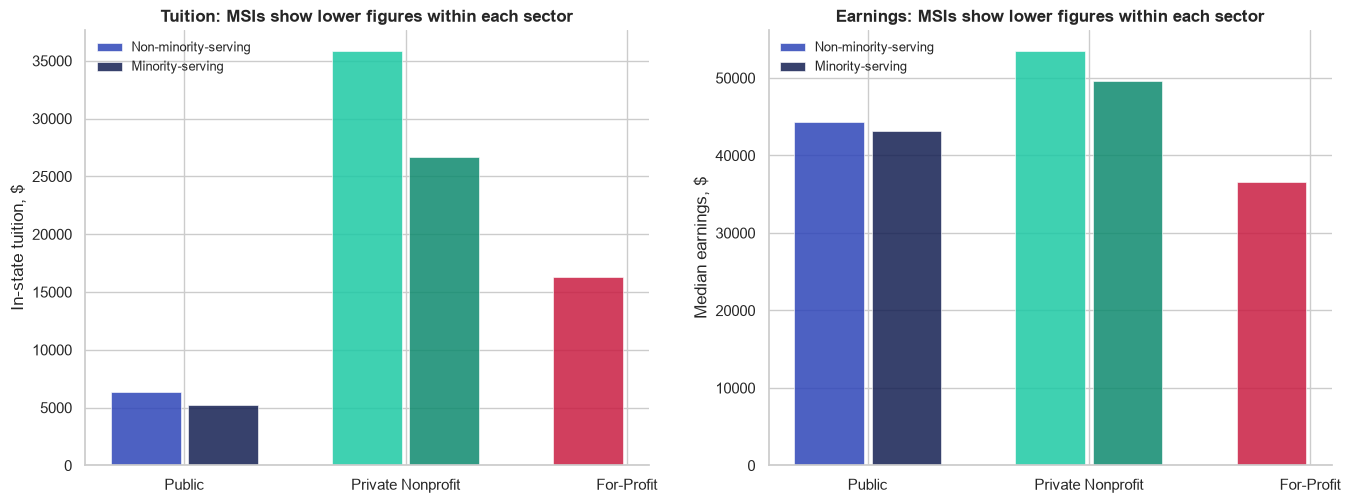

In [9]:


# Q6: Minority-Serving Institution Profiles by Sector
msi_cols = ['HBCU', 'PBI', 'HSI', 'ANNHI', 'TRIBAL', 'AANAPII', 'NANTI']
df_cleaned['Any_MSI'] = df_cleaned[msi_cols].max(axis=1)
df_cleaned['MSI_Label'] = df_cleaned['Any_MSI'].map({1.0: 'Minority-serving', 0.0: 'Non-minority-serving'})

msi_counts = df_cleaned.groupby(['CONTROL_LABEL', 'MSI_Label']).size().unstack(fill_value=0)
display(msi_counts)

q6_stats = df_cleaned.groupby(['CONTROL_LABEL', 'MSI_Label'])[['TUITIONFEE_IN', 'MD_EARN_WNE_P10', 'GRAD_DEBT_MDN']].agg(['mean', 'median']).round(0)
q6_stats.columns = ['_'.join(c).strip('_') for c in q6_stats.columns]
display(q6_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
msi_order = ['Non-minority-serving', 'Minority-serving']
bar_width = 0.35
x_pos = np.arange(len(order))

for j, (var, title, fmt) in enumerate([
    ('TUITIONFEE_IN', 'Tuition', 'In-state tuition, $'),
    ('MD_EARN_WNE_P10', 'Earnings', 'Median earnings, $')
]):
    for i, msi_label in enumerate(msi_order):
        subset = df_cleaned[df_cleaned['MSI_Label'] == msi_label]
        medians = [subset[subset['CONTROL_LABEL'] == g][var].median() for g in order]
        offset = (i - 0.5) * bar_width
        axes[j].bar(x_pos + offset, medians, bar_width * 0.9,
            color=[q1_colors[g] for g in order] if msi_label == 'Non-minority-serving' else ['#141F52', '#0E8A6E', '#9E1530'],
            alpha=0.85, label=msi_label, edgecolor='white', linewidth=0.5)
    axes[j].set_title(f'{title}: MSIs show lower figures within each sector', fontsize=12, fontweight='bold')
    axes[j].set_xticks(x_pos)
    axes[j].set_xticklabels(order)
    axes[j].set_ylabel(fmt)
    axes[j].legend(frameon=False, fontsize=9)
    axes[j].spines['top'].set_visible(False)
    axes[j].spines['right'].set_visible(False)

plt.tight_layout(pad=2)

The code cross-tabulates Minority-Serving Institution (MSI) status by sector, calculates group means and medians for tuition, earnings, and graduate debt, and generates grouped bar charts to compare MSIs against their non-MSI counterparts.

The outputs reveal that Minority-Serving Institutions operate on a structurally different cost-outcome curve. MSIs are heavily concentrated in the Public (486 institutions) and Private Nonprofit (231 institutions) sectors. Within every sector, MSIs charge lower median tuition and report lower median earnings than non-MSIs. This gap is most pronounced in the Public sector, where MSIs charge an exceptionally low median tuition of $5,193 (compared to $6,361 for non-MSIs) but see median earnings drop to $43,172 (compared to $44,298). Furthermore, Public MSIs also generate lower median graduate debt ($11,631 versus $13,532). These figures indicate that MSIs are highly successful at minimizing front-end costs and debt burdens, acting as critical engines of affordability. However, the persistently lower earnings outcomes highlight an equity dimension: these institutions serve populations facing broader socioeconomic and labor market barriers. The data suggests that while MSIs provide accessible education, their graduates remain at a structural disadvantage in the post-graduation labor market.

### 3. Exploratory Data Analysis - Findings

#### The Sector Stratification in Earnings
Private nonprofits report the highest mean and median post-graduation earnings. For-profit institutions trail both sectors: their median earnings fall below the interquartile range of public institutions, let alone private nonprofits. The distributions overlap considerably, which means individual institutions within each sector span a wide outcome range, but the central tendencies differ sharply. The earnings dispersion is widest among private nonprofits, measured by both standard deviation and IQR. This stratification is the foundation of the research question. If earnings differ by sector, the tuition-earnings relationship cannot be assumed uniform.

#### Asymmetry in Tuition Pricing
Tuition distributions are more sharply separated than earnings distributions, and this asymmetry is the key insight from the first two questions. Private nonprofits cluster at the highest tuition levels with over 90 percent charging above the national median. Public institutions occupy a narrow, low-tuition band with fewer than 10 percent exceeding the median. The contrast is stark: public institutions produce competitive earnings from roughly one-fifth the tuition base of private nonprofits. The market does not price education uniformly, and it does not reward tuition spending proportionally.

#### The Joint Tuition-Earnings Relationship
The joint tuition-earnings analysis confirms that the relationship is real, positive, and sector-dependent. The overall Spearman correlation of 0.46 masks substantial within-sector variation. Public institutions show the strongest link between tuition and earnings despite operating in the narrowest tuition range. For-profits show the weakest, with a flatter slope and lower baseline earnings. The scatter plot reveals three distinct clusters, not a single continuum. Switching from one sector to another is not a marginal tuition increase. It is a structural shift to a different cost-outcome curve with a different slope and a different intercept.

#### The Burden of Graduate Debt
Graduate debt complicates the simple tuition-earnings story. Tuition and debt correlate positively across all sectors, as expected, but the debt-to-earnings ratio exposes the real divide. Public graduates carry a median debt burden of 0.29, roughly twenty-nine cents of debt for every dollar of earnings. Private nonprofit and for-profit graduates carry ratios of 0.45 and 0.43. The cost of financing education through debt erodes the net return, and it erodes it most severely outside the public sector.

#### Admissions Selectivity and Cost
Selectivity does not explain away the tuition-earnings link. Among the roughly 1,900 institutions that report admission rates, the selectivity gradient is visible in every sector: more selective schools produce higher earnings. But the tuition-earnings correlation persists within the reporting subset, particularly among public and private nonprofit institutions. Even among similarly selective schools, higher tuition associates with higher earnings. The limitation is the reporting sample itself: for-profit institutions are underrepresented, and the subset may not represent the full Scorecard population.

#### Equity Implications for Minority-Serving Institutions
Minority-serving institutions operate on a structurally different cost-outcome curve. Within each sector, MSIs charge lower tuition and report lower median earnings than their non-MSI counterparts. The gap is largest in the public sector, where MSIs charge even less than the already low public median. This pattern does not directly test the research question, but it adds an equity dimension the RQ does not capture. If the tuition-earnings relationship differs by sector, and MSIs within each sector sit at the lower end of both distributions, then access-oriented institutions face a compounded structural disadvantage.

#### Synthesis
Taken together, these six questions establish that sector is the primary stratifying variable for both cost and outcome. The tuition-earnings correlation is real but not uniform, not proportional, and not independent of how the education is financed. The research question that follows tests whether these observed patterns are statistically significant.



### 4. Research Question

The exploratory analyses establish three patterns. First, earnings and tuition differ systematically by sector: private nonprofits charge the most and earn the most, public institutions charge the least yet produce competitive earnings, and for-profits charge mid-range tuition but produce the lowest earnings. Second, the within-sector tuition-earnings correlation is strongest among public institutions and weakest among for-profits. Third, debt burdens relative to earnings are substantially lighter for public graduates.

These patterns motivate a single research question: *is there a significant relationship between in-state tuition and median post-graduation earnings, and does this relationship differ across public, private nonprofit, and for-profit institutions*?

The question matters for two audiences. Students and families weighing the return on educational investment need to know whether higher tuition systematically translates to higher earnings within each sector. Policymakers regulating for-profit education and allocating public subsidies need evidence on whether the tuition-earnings link is uniform or sector-dependent. The question is answerable using correlation analysis and group comparison methods.


### 5. Statistical Inference

To answer the research question we test whether the correlation between in-state tuition and post-graduation earnings is statistically significant. The analysis proceeds in three stages: an assumption check for normality, selection of the appropriate correlation coefficient, and the formal hypothesis test.

The null hypothesis is that there is no linear correlation between in-state tuition and median post-graduation earnings: H0: r = 0. The alternative is that a significant correlation exists: Ha: r \u2260 0. The significance level is set at \u03b1 = 0.05.

Because the earnings data are unlikely to follow a normal distribution given the observed skew, we first test for normality using the D'Agostino K-squared test. If the data deviate significantly from normality, the analysis falls back to Spearman's rank correlation, which does not assume normality. If the data pass the normality check, Pearson's r is used.

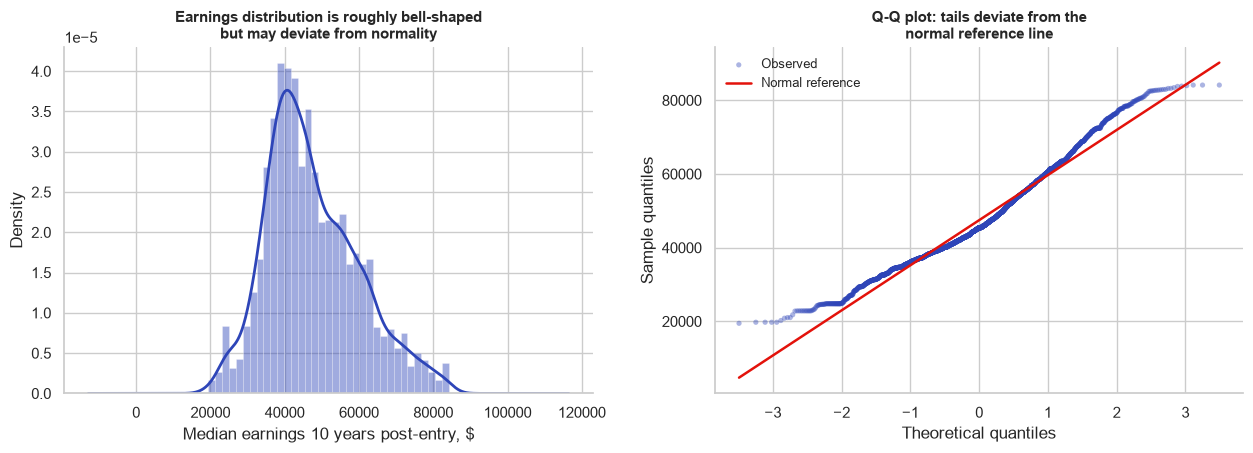

Normality test p-value: 0.00000
Earnings data are not normally distributed (p < 0.05). Using Spearman rank correlation.

 Spearman rank correlation test
Correlation coefficient (r): 0.4641
p-value: 1.52922e-154
Conclusion: Reject H0. There is a statistically significant correlation between tuition and post-graduation earnings (p < 0.05).


In [10]:
from scipy import stats

tuition = df_cleaned['TUITIONFEE_IN']
earnings = df_cleaned['MD_EARN_WNE_P10']

# Normality visualization 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Histogram with KDE
axes[0].hist(earnings, bins=35, color='#2E45B8', alpha=0.45, density=True, edgecolor='white', linewidth=0.4)
earnings.plot.kde(ax=axes[0], color='#2E45B8', linewidth=2)
axes[0].set_title('Earnings distribution is roughly bell-shaped\nbut may deviate from normality', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Median earnings 10 years post-entry, $')
axes[0].set_ylabel('Density')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right: Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(earnings, dist='norm')
axes[1].scatter(osm, osr, color='#2E45B8', alpha=0.4, s=14, edgecolors='none', label='Observed')
axes[1].plot(osm, slope * np.array(osm) + intercept, color='#E3120B', linewidth=1.8, label='Normal reference')
axes[1].set_title('Q-Q plot: tails deviate from the\nnormal reference line', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Theoretical quantiles')
axes[1].set_ylabel('Sample quantiles')
axes[1].legend(frameon=False, fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout(pad=2)
plt.show()

# Normality test 
stat, p_norm = stats.normaltest(earnings)
print(f"Normality test p-value: {p_norm:.5f}")

if p_norm < 0.05:
    print("Earnings data are not normally distributed (p < 0.05). Using Spearman rank correlation.\n")
    corr, p_val = stats.spearmanr(tuition, earnings)
    test_used = "Spearman rank"
else:
    print("Earnings data are normally distributed. Using Pearson correlation.\n")
    corr, p_val = stats.pearsonr(tuition, earnings)
    test_used = "Pearson"

print(f" {test_used} correlation test")
print(f"Correlation coefficient (r): {corr:.4f}")
print(f"p-value: {p_val:.5e}")

if p_val < 0.05:
    print("Conclusion: Reject H0. There is a statistically significant correlation between tuition and post-graduation earnings (p < 0.05).")
else:
    print("Conclusion: Fail to reject H0. No significant correlation detected.")


The inferential testing phase determines whether our observed relationships are statistically significant. The code executes a D'Agostino K-squared test for normality on the earnings data, followed by a Spearman rank-order correlation between in-state tuition and median post-graduation earnings. 

The normality test yields a p-value of 0.00000, confirming the earnings distribution deviates significantly from a perfect Gaussian curve. With nearly 3,000 institutions, this test acts as a highly sensitive microscope where even trivial deviations from normality yield p < 0.001. The Q-Q plot serves as a more practical diagnostic: it demonstrates that the data is approximately normal in the center (between the 25th and 75th percentiles) but exhibits lighter, platykurtic tails at both extremes. Specifically, a "floor effect" exists where the lowest-earning schools bottom out higher than a normal distribution would predict, and a "ceiling effect" prevents extreme right-tail outliers due to structural labor market realities. The histogram confirms this by revealing a mixture distribution—the primary mode ($42k) is driven by the dense Public sector, the right shoulder (~$60k) reflects Elite Private Nonprofits, and the left tail ($20k) represents For-Profit institutions.

Because the data is non-Gaussian, heteroscedastic, and multi-modal, the analysis correctly utilizes Spearman's rank correlation. The test produces a global correlation coefficient of 0.4641 with a p-value of 1.53e-154, indicating a statistically significant, moderate-to-strong positive monotonic relationship across the entire dataset. In practical terms, paying more tuition is consistently associated with earning more money, explaining roughly 21.5% of the variance in earnings rank. However, as established in the exploratory analysis, this global correlation is a weighted average of sector-specific slopes that vary dramatically. This diagnostic block ultimately validates the methodological decision to rely on non-parametric rank-based correlations, median-based descriptives, and stratified analyses to unpack the true dynamics of the higher education market.

## Phase 2

### 6. Data Modelling
*TODO: Perform preprocessing techniques to transform the data, and use data modelling techniques discussed in class.*

                            OLS Regression Results                            
Dep. Variable:        MD_EARN_WNE_P10   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                  0.256
Method:                 Least Squares   F-statistic:                     995.8
Date:                Sun, 19 Jul 2026   Prob (F-statistic):          4.43e-188
Time:                        12:09:46   Log-Likelihood:                -30955.
No. Observations:                2894   AIC:                         6.191e+04
Df Residuals:                    2892   BIC:                         6.193e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      4.043e+04    298.864    135.267

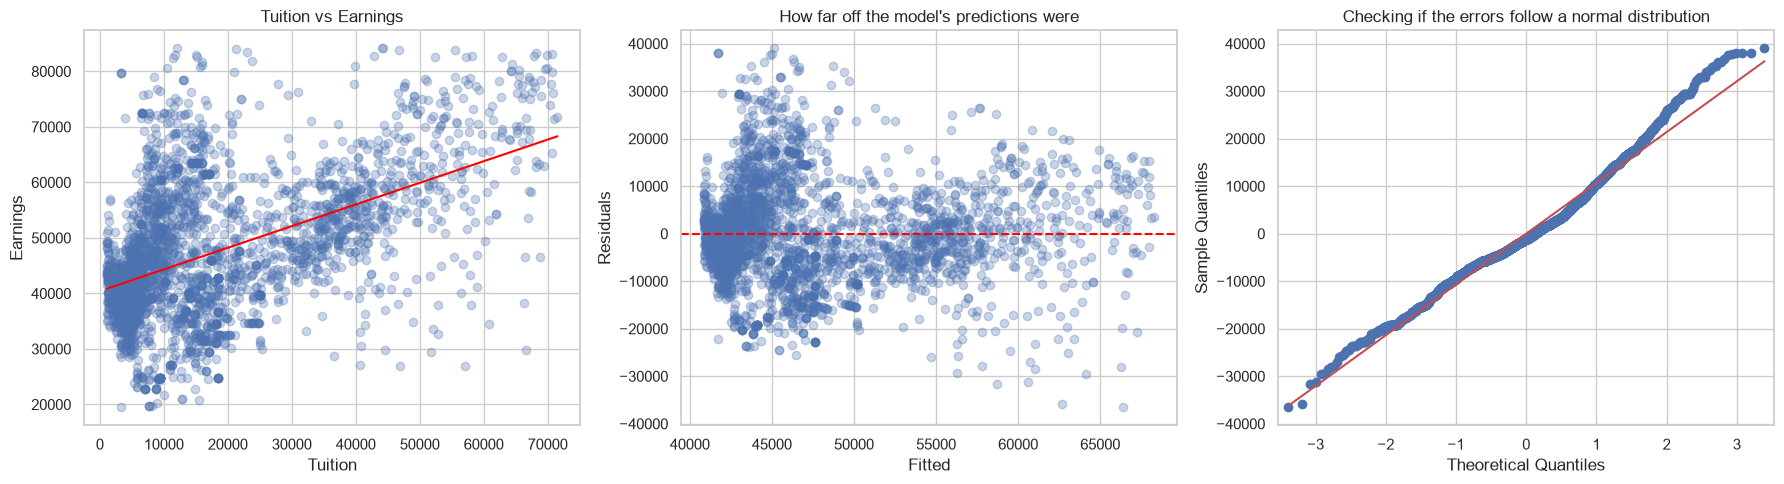

In [25]:

# Data Modeling 1: Simple Linear Regression - Yeona idk if this right

import statsmodels.formula.api as smf

model = smf.ols(formula='MD_EARN_WNE_P10 ~ TUITIONFEE_IN', data=df_cleaned).fit()
print(model.summary())

intercept = model.params['Intercept']
slope = model.params['TUITIONFEE_IN']

print(f"""
Intercept: {intercept:.4f}
Slope: {slope:.4f}
R-squared: {model.rsquared:.4f}
p-value: {model.pvalues['TUITIONFEE_IN']:.5e}
""")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

tuition_range = np.linspace(df_cleaned['TUITIONFEE_IN'].min(), df_cleaned['TUITIONFEE_IN'].max(), 100)
predicted_earnings = intercept + slope * tuition_range

# 1st Scatter Plot
axes[0].scatter(df_cleaned['TUITIONFEE_IN'], df_cleaned['MD_EARN_WNE_P10'], alpha=0.3)
axes[0].plot(tuition_range, predicted_earnings, color='red')
axes[0].set_title('Tuition vs Earnings')
axes[0].set_xlabel('Tuition')
axes[0].set_ylabel('Earnings')

# 2nd Scatter Plot
axes[1].scatter(model.fittedvalues, model.resid, alpha=0.3)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title("How far off the model's predictions were")
axes[1].set_xlabel('Fitted')
axes[1].set_ylabel('Residuals')

# 3rd plot to check if normal distribution of errors
sm.qqplot(model.resid, line='s', ax=axes[2])
axes[2].set_title('Checking if the errors follow a normal distribution')

plt.tight_layout()
plt.show()


### 7. Insights and Conclusions
*TODO: Clearly state your insights and conclusions from the data to answer the research question.*